In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.IPAT1R import Trajectory1PAT1R
import matplotlib.pyplot as plt
import numpy as np

# ODE

In [2]:
ode = Trajectory1PAT1R()

Output()

In [3]:
m1 = 1e6       # primary mass [solar masses]
m2 = 1e6       # secondary mass [solar masses]

a  = -0.2       # primary spin chi1 (dimensionless)
chit2  = -0.1   # secondary spin
deltaM = 0.0

In [4]:
ode.add_fixed_parameters(m1, m2, a, [chit2])
r_values = np.linspace(6.0, 15.0, 1000)
rdot_values = [ode.evaluate_rhs([r, 0.0, 1.0, 0.0, 0.0, 0.0, deltaM, chit2])[0] for r in r_values]
chit1dot_values = [ode.evaluate_rhs([r, 0.0, 1.0, 0.0, 0.0, 0.0, deltaM, chit2])[-1] for r in r_values]
deltaMdot_values = [ode.evaluate_rhs([r, 0.0, 1.0, 0.0, 0.0, 0.0, deltaM, chit2])[-2] for r in r_values]

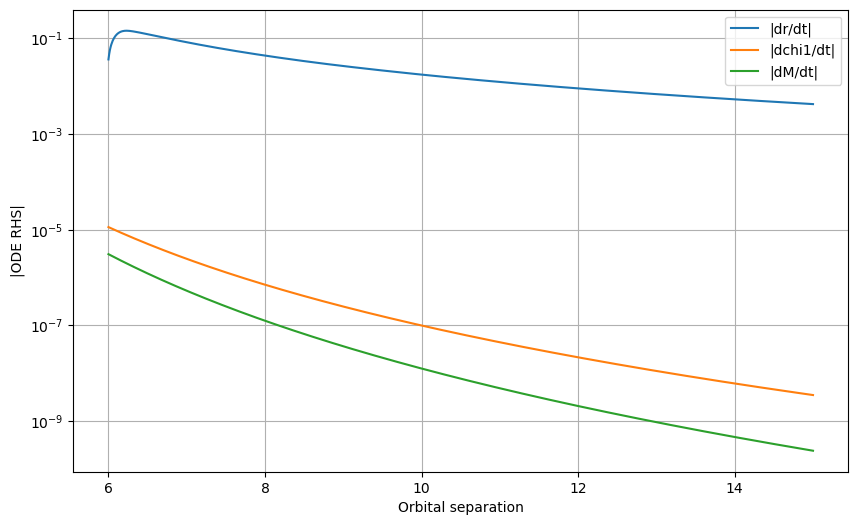

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(r_values, np.abs(rdot_values), label="|dr/dt|")
plt.plot(r_values, np.abs(chit1dot_values), label="|dchi1/dt|")
plt.plot(r_values, np.abs(deltaMdot_values), label="|dM/dt|")
plt.legend()
plt.xlabel("Orbital separation")
plt.ylabel("|ODE RHS|")
plt.yscale("log")
plt.grid()
plt.show()

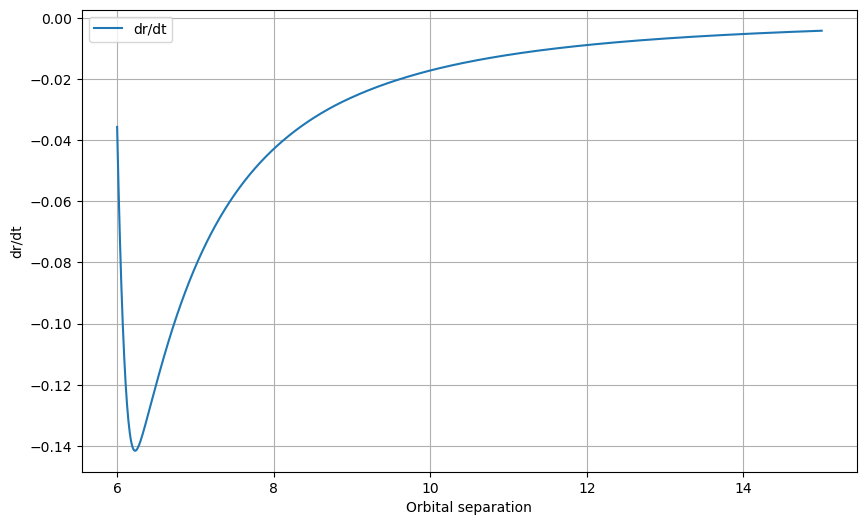

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(r_values, rdot_values, label="dr/dt")
plt.legend()
plt.xlabel("Orbital separation")
plt.ylabel("dr/dt")
plt.grid()
plt.show()

# Trajectory

In [7]:
traj = EMRIInspiral(func=Trajectory1PAT1R)

In [8]:
m1 = 1e6       # primary mass [solar masses]
m2 = 1e6       # secondary mass [solar masses]

a  = -0.2       # primary spin chi1 (dimensionless)
chi2  = -0.1   # secondary spin
p0 = 15.0      # initial orbital separation [M]

dt = 1.   # time step [s]
T  = 1    # total duration [yr]

In [9]:
t, p, e, x, Phi_phi, Phi_theta, Phi_r, deltaM, deltachit1 = traj(
    m1, m2,
    a,        # chi1 (primary spin)
    p0,
    0.0,      # e0: circular
    1.0,      # xI: equatorial prograde
    chi2,
    T=T,
    dt=dt,
    in_coordinate_time=False
)

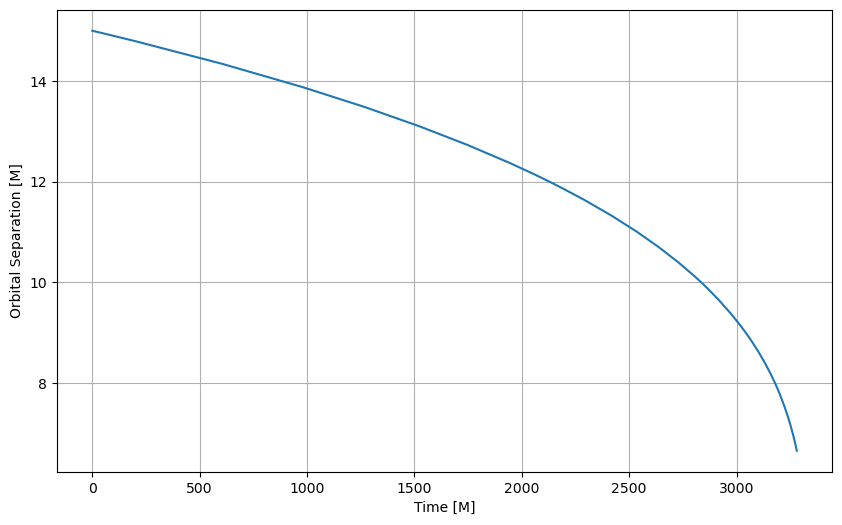

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(t, p)
plt.xlabel("Time [M]")
plt.ylabel("Orbital Separation [M]")
plt.grid()
plt.show()

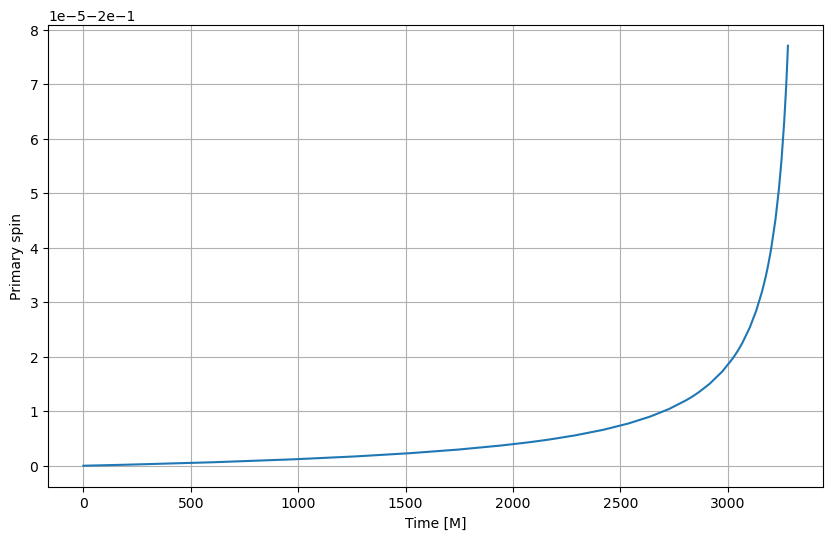

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(t, a + deltachit1)
plt.xlabel("Time [M]")
plt.ylabel("Primary spin")
plt.grid()
plt.show()

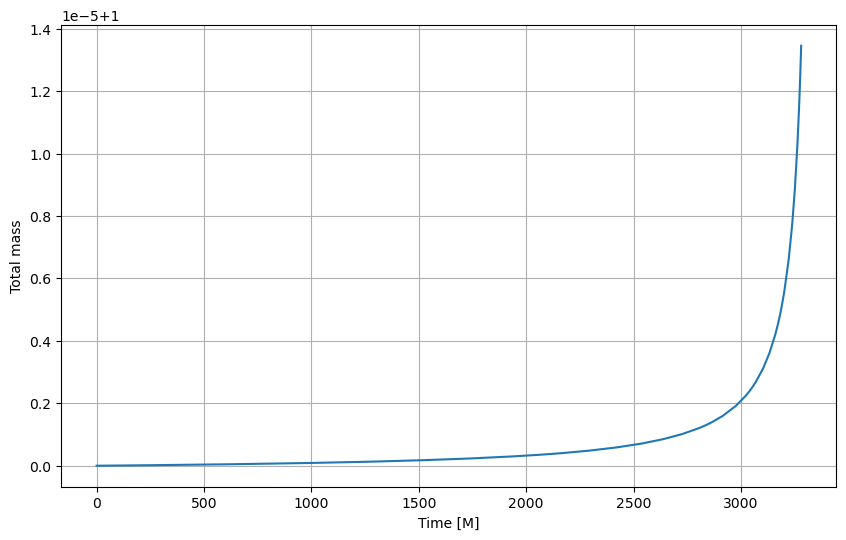

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(t, 1 + deltaM)
plt.xlabel("Time [M]")
plt.ylabel("Total mass")
plt.grid()
plt.show()

# Random sample

In [13]:
ode = Trajectory1PAT1R()

min_p = ode._min_p
max_p = ode._max_p

min_logm = -1.0
max_logm = 10.0

min_chi1 = ode._min_chi1
max_chi1 = ode._max_chi1

min_chi2 = ode._min_chi2
max_chi2 = ode._max_chi2

N_TESTS = 2000
dt = 1.   # time step [s]
T  = 100    # total duration [yr]

In [14]:
#p = np.random.uniform(min_p, max_p, N_TESTS)
logm1 = np.random.uniform(min_logm, max_logm, N_TESTS)
logm2 = np.random.uniform(min_logm, max_logm, N_TESTS)
m1 = np.array([10.**np.max([logm1[i], logm2[i]]) for i in range(N_TESTS)])
m2 = np.array([10.**np.min([logm1[i], logm2[i]]) for i in range(N_TESTS)])
nu = m1 * m2 / (m1 + m2)**2.
chi1 = np.random.uniform(min_chi1, max_chi1, N_TESTS)
chi2 = np.random.uniform(min_chi2, max_chi2, N_TESTS)

p = np.array([np.random.uniform(*ode.bounds_p(0.0, 1.0, chi1[i], p_buffer=[0.01,0.0])) for i in range(N_TESTS)])

In [15]:
failed_indices = []
for i in range(N_TESTS):
    traj = EMRIInspiral(func=Trajectory1PAT1R)
    try:
        traj(
            m1[i], m2[i],
            chi1[i],        # chi1 (primary spin)
            p[i],
            0.0,      # e0: circular
            1.0,      # xI: equatorial prograde
            chi2[i],
            T=T,
            dt=dt,
            in_coordinate_time=False
        )
    except (ValueError, AssertionError) as e:
        print(f"  -> ValueError at i={i}: {e}")
        failed_indices.append(i)

print(f"\nFailed indices: {failed_indices}")



Failed indices: []


In [16]:
mask = np.ones(N_TESTS, dtype=bool)
mask[failed_indices] = False

nu_failed = nu[~mask]
chi1_failed = chi1[~mask]
chi2_failed = chi2[~mask]
p_failed = p[~mask]

nu_success = nu[mask]
chi1_success = chi1[mask]
chi2_success = chi2[mask]
p_success = p[mask]

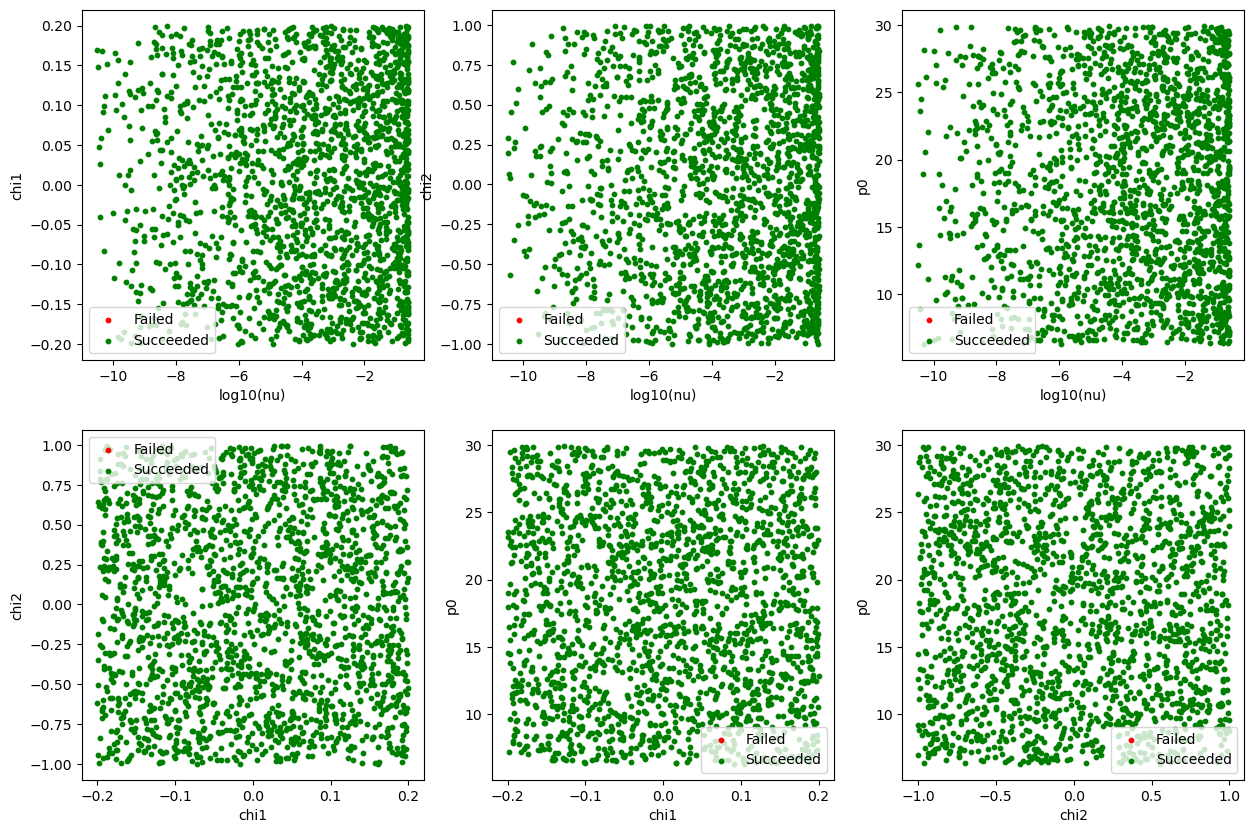

In [17]:
fig, axs = plt.subplots(2,3,figsize=(15,10))

axs[0,0].scatter(np.log10(nu_failed), chi1_failed, color='red', label='Failed', s=10)
axs[0,0].scatter(np.log10(nu_success), chi1_success, color='green', label='Succeeded', s=10)
axs[0,0].set_xlabel('log10(nu)')
axs[0,0].set_ylabel('chi1')
axs[0,0].legend()

axs[0,1].scatter(np.log10(nu_failed), chi2_failed, color='red', label='Failed', s=10)
axs[0,1].scatter(np.log10(nu_success), chi2_success, color='green', label='Succeeded', s=10)
axs[0,1].set_xlabel('log10(nu)')
axs[0,1].set_ylabel('chi2')
axs[0,1].legend()

axs[0,2].scatter(np.log10(nu_failed), p_failed, color='red', label='Failed', s=10)
axs[0,2].scatter(np.log10(nu_success), p_success, color='green', label='Succeeded', s=10)
axs[0,2].set_xlabel('log10(nu)')
axs[0,2].set_ylabel('p0')
axs[0,2].legend()

axs[1,0].scatter(chi1_failed, chi2_failed, color='red', label='Failed', s=10)
axs[1,0].scatter(chi1_success, chi2_success, color='green', label='Succeeded', s=10)
axs[1,0].set_xlabel('chi1')
axs[1,0].set_ylabel('chi2')
axs[1,0].legend()

axs[1,1].scatter(chi1_failed, p_failed, color='red', label='Failed', s=10)
axs[1,1].scatter(chi1_success, p_success, color='green', label='Succeeded', s=10)
axs[1,1].set_xlabel('chi1')
axs[1,1].set_ylabel('p0')
axs[1,1].legend()

axs[1,2].scatter(chi2_failed, p_failed, color='red', label='Failed', s=10)
axs[1,2].scatter(chi2_success, p_success, color='green', label='Succeeded', s=10)
axs[1,2].set_xlabel('chi2')
axs[1,2].set_ylabel('p0')
axs[1,2].legend()

plt.show()